In [ ]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

# Backward-compatible alias
color_values = OKABE_ITO_CYCLE

In [ ]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Theoretical calculations by Helen"
PLOTS_DIR    = PROJECT_ROOT / "figures"
PLOTS_DIR.mkdir(exist_ok=True)

In [4]:


excel_path = os.path.join(RAW_DATA_DIR,"CrSBr_magnetization map along c_22052025.xlsx")
excel_file = pd.ExcelFile(excel_path)

# Filter sheets starting from 'Sheet3' onward
relevant_sheets = [s for s in excel_file.sheet_names if s.startswith("Sheet") and int(s[5:]) >= 3]

# Remove any sheets that are too short (e.g., empty or metadata-only)
relevant_sheets = [s for s in relevant_sheets if excel_file.parse(s, header=None).shape[0] >= 5]

# Function to clean 'x' values by removing imaginary parts and converting to float
def clean_complex_column(series):
    clean_series = series.astype(str).str.replace(r'\+.*i', '', regex=True).str.strip()
    clean_series = clean_series.replace("Inf", np.inf)
    return pd.to_numeric(clean_series, errors="coerce")

relevant_sheets = [
    s for s in excel_file.sheet_names
    if s.startswith("Sheet") and excel_file.parse(s, header=None).shape[0] >= 5]

print(relevant_sheets)



['Sheet11', 'Sheet10', 'Sheet9', 'Sheet8', 'Sheet4', 'Sheet3', 'Sheet1', 'Sheet2', 'Sheet5', 'Sheet7']


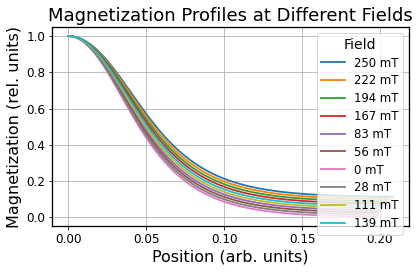

In [5]:
# Read and clean all relevant sheets
data_dict = {}

for sheet in relevant_sheets:
    df = excel_file.parse(sheet_name=sheet, header=None)
    field_value = df.iloc[1, 0]
    data = df.iloc[4:, [0, 2]]  # position and magnetization
    data.columns = ["x", "y"]
    data = data.dropna()

    # Convert all to float
    data["x"] = clean_complex_column(data["x"])
    data["y"] = pd.to_numeric(data["y"], errors="coerce")
    data = data.dropna()
    data["field"] = float(field_value)

    data_dict[sheet] = data

# Plot
plt.figure(figsize=(6, 4))
for name, df in data_dict.items():
    plt.plot(df["x"], df["y"], label=f"{round(df['field'].iloc[0])} mT")

plt.xlabel("Position (arb. units)")
plt.ylabel("Magnetization (rel. units)")
plt.title("Magnetization Profiles at Different Fields")
plt.legend(title="Field", fontsize="small", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

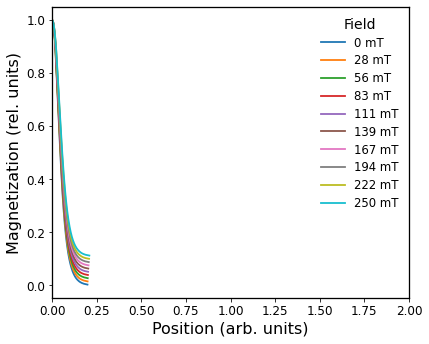

In [6]:
# Sort the data_dict by field values
sorted_items = sorted(data_dict.items(), key=lambda item: item[1]['field'].iloc[0])

# Plot the sorted data
plt.figure(figsize=(6, 5))
for name, df in sorted_items:
    plt.plot(df["x"], df["y"], label=f"{round(df['field'].iloc[0])} mT")

plt.xlabel("Position (arb. units)")
plt.ylabel("Magnetization (rel. units)")
plt.legend(title="Field", fontsize="small", loc="best", frameon=False)

plt.tight_layout()
plt.xlim(0,2)
plt.savefig(os.path.join(PLOTS_DIR,"theory_MvC_CSB.png"))
plt.show()


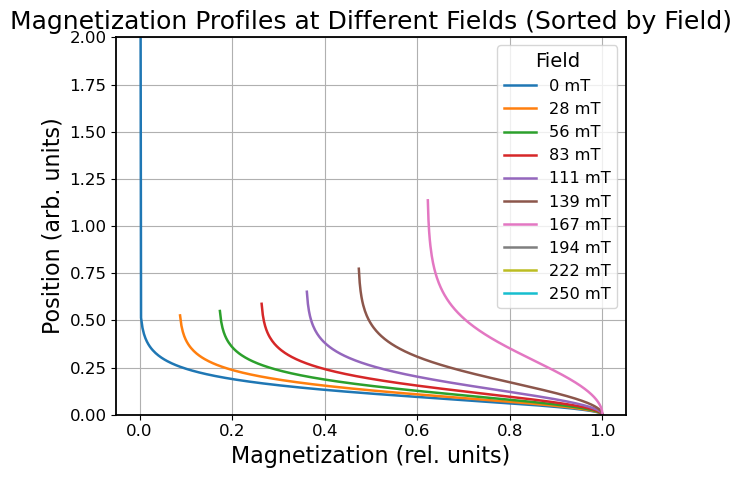

In [22]:

sorted_items = sorted(data_dict.items(), key=lambda item: item[1]['field'].iloc[0])

# Plot the sorted data
plt.figure(figsize=(6, 5))
for name, df in sorted_items:
    plt.plot( df["y"],df["x"], label=f"{round(df['field'].iloc[0])} mT")

plt.ylabel("Position (arb. units)")
plt.xlabel("Magnetization (rel. units)")
plt.title("Magnetization Profiles at Different Fields (Sorted by Field)")
plt.legend(title="Field", fontsize="small", loc="best")
plt.grid(True)
plt.tight_layout()
plt.ylim(0,2)
plt.show()

In [ ]:
# Sort the data_dict by field values
sorted_items = sorted(data_dict.items(), key=lambda item: item[1]['field'].iloc[0])

# Plot the sorted data
plt.figure(figsize=(6, 5))
for name, df in sorted_items:
    plt.plot( df["y"],df["x"], label=f"{round(df['field'].iloc[0])} mT")

plt.ylabel("Position (arb. units)")
plt.xlabel("Magnetization (rel. units)")
plt.title("Magnetization Profiles at Different Fields (Sorted by Field)")
plt.legend(title="Field", fontsize="small", loc="best")
plt.grid(True)
plt.tight_layout()
plt.ylim(0,2)
plt.show()

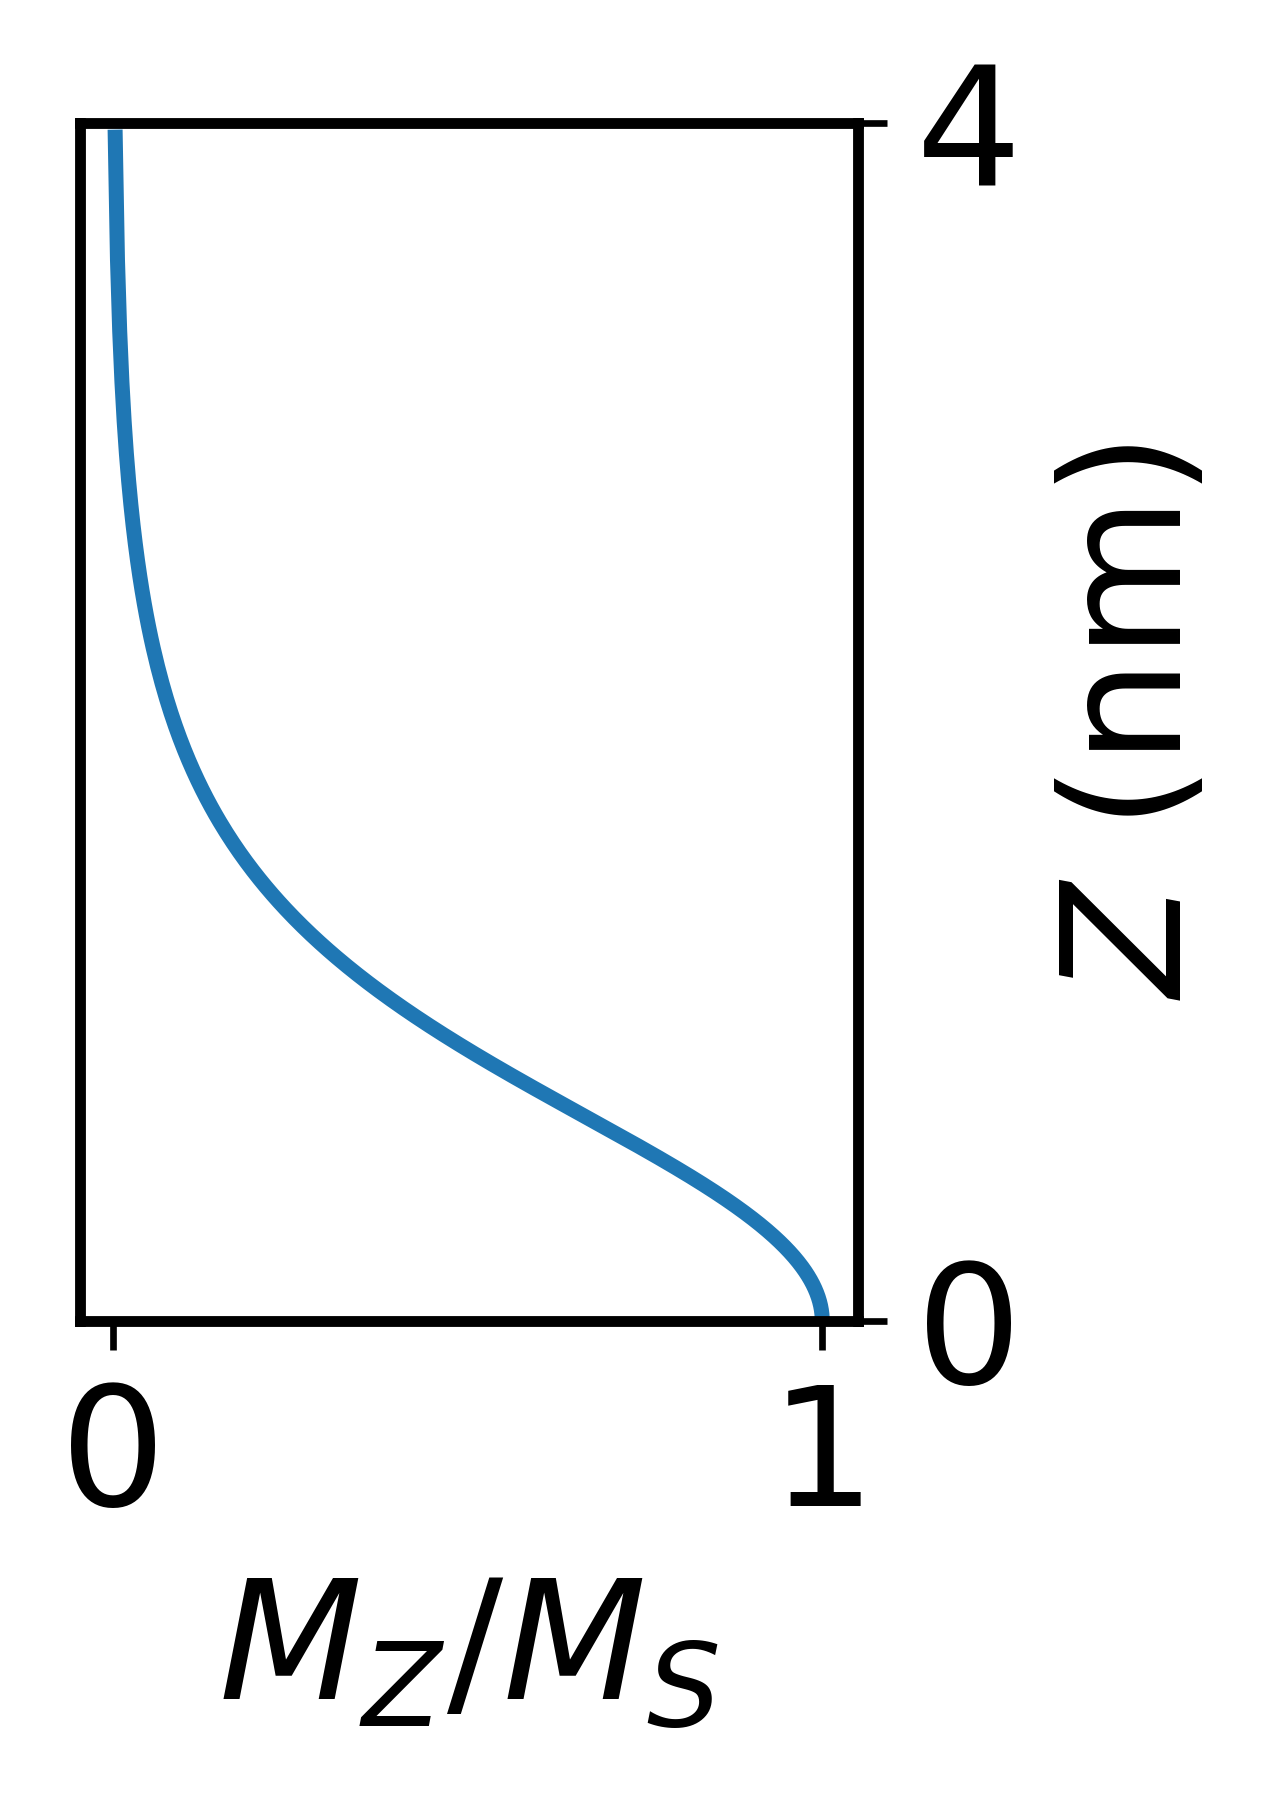

In [29]:
# Plot the magnetization profile for the sheet with field ≈ 27.78 mT
plt.figure(figsize=(2.3, 3), dpi = 600)
plt.gca().yaxis.tick_right()
plt.gca().yaxis.set_label_position("right")
for name, df in data_dict.items():
    if np.isclose(df["field"].iloc[0], 0, rtol=1e-3):
        plt.plot( df["y"], df["x"]*20,label=f"{df['field'].iloc[0]:.2f} mT")

plt.xlabel("$M_Z/M_S$",fontsize=20)
plt.ylabel("$Z$ (nm)", fontsize=20)
plt.tight_layout()
plt.tick_params(axis='both', labelsize=20)
plt.ylim([0,0.4])
plt.yticks([0, 4])
plt.xticks([0,1])

plt.savefig(os.path.join(PLOTS_DIR,"schematic_inset.png"))

